In [2]:
import pandas as pd                  # Data manipulation
import numpy as np                   # Numerical operations
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [4]:
df = pd.read_csv("dataset_part_2.csv")

df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [5]:
df.columns.tolist()

['FlightNumber',
 'Date',
 'BoosterVersion',
 'PayloadMass',
 'Orbit',
 'LaunchSite',
 'Outcome',
 'Flights',
 'GridFins',
 'Reused',
 'Legs',
 'LandingPad',
 'Block',
 'ReusedCount',
 'Serial',
 'Longitude',
 'Latitude',
 'Class']

In [6]:
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [7]:
print(df.shape)
print(df.info())
print(df.columns)

(90, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   FlightNumber    90 non-null     int64  
 1   Date            90 non-null     object 
 2   BoosterVersion  90 non-null     object 
 3   PayloadMass     90 non-null     float64
 4   Orbit           90 non-null     object 
 5   LaunchSite      90 non-null     object 
 6   Outcome         90 non-null     object 
 7   Flights         90 non-null     int64  
 8   GridFins        90 non-null     bool   
 9   Reused          90 non-null     bool   
 10  Legs            90 non-null     bool   
 11  LandingPad      64 non-null     object 
 12  Block           90 non-null     float64
 13  ReusedCount     90 non-null     int64  
 14  Serial          90 non-null     object 
 15  Longitude       90 non-null     float64
 16  Latitude        90 non-null     float64
 17  Class           90 non-null 

In [8]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 90
Columns : 18


In [9]:
df.columns

Index(['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit',
       'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs',
       'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude',
       'Class'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   FlightNumber    90 non-null     int64  
 1   Date            90 non-null     object 
 2   BoosterVersion  90 non-null     object 
 3   PayloadMass     90 non-null     float64
 4   Orbit           90 non-null     object 
 5   LaunchSite      90 non-null     object 
 6   Outcome         90 non-null     object 
 7   Flights         90 non-null     int64  
 8   GridFins        90 non-null     bool   
 9   Reused          90 non-null     bool   
 10  Legs            90 non-null     bool   
 11  LandingPad      64 non-null     object 
 12  Block           90 non-null     float64
 13  ReusedCount     90 non-null     int64  
 14  Serial          90 non-null     object 
 15  Longitude       90 non-null     float64
 16  Latitude        90 non-null     float64
 17  Class           90 non-null     int64

In [11]:
# Missing values

df.isnull().sum().sort_values(ascending=False)

,0
LandingPad,26
FlightNumber,0
Date,0
BoosterVersion,0
Orbit,0
PayloadMass,0
Outcome,0
Flights,0
GridFins,0
LaunchSite,0


In [12]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100,2)
})

missing

,Missing Values,Percentage
FlightNumber,0,0.00
Date,0,0.00
BoosterVersion,0,0.00
PayloadMass,0,0.00
Orbit,0,0.00
LaunchSite,0,0.00
Outcome,0,0.00
Flights,0,0.00
GridFins,0,0.00
Reused,0,0.00


In [13]:
print("Duplicate Rows :", df.duplicated().sum())

df = df.drop_duplicates()

print("New Shape :", df.shape)

Duplicate Rows : 0
New Shape : (90, 18)


In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
FlightNumber,90.0,45.500000,26.124701,1.000000,23.250000,45.500000,67.750000,90.000000
PayloadMass,90.0,6104.959412,4694.671720,350.000000,2510.750000,4701.500000,8912.750000,15600.000000
Flights,90.0,1.788889,1.213172,1.000000,1.000000,1.000000,2.000000,6.000000
Block,90.0,3.500000,1.595288,1.000000,2.000000,4.000000,5.000000,5.000000
ReusedCount,90.0,1.655556,1.710254,0.000000,0.000000,1.000000,3.000000,5.000000
Longitude,90.0,-86.366477,14.149518,-120.610829,-80.603956,-80.577366,-80.577366,-80.577366
Latitude,90.0,29.449963,2.141306,28.561857,28.561857,28.561857,28.608058,34.632093
Class,90.0,0.666667,0.474045,0.000000,0.000000,1.000000,1.000000,1.000000


In [15]:
df['Class'].value_counts()

,count
Class,
1,60
0,30


In [16]:
success = df['Class'].value_counts(normalize=True) * 100
print(success)

Class
1    66.666667
0    33.333333
Name: proportion, dtype: float64


In [17]:
print("Shape of Dataset:", df.shape)

display(df.head())

display(df.describe())

Shape of Dataset: (90, 18)


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Longitude,Latitude,Class
count,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000
mean,45.500000,6104.959412,1.788889,3.500000,1.655556,-86.366477,29.449963,0.666667
std,26.124701,4694.671720,1.213172,1.595288,1.710254,14.149518,2.141306,0.474045
min,1.000000,350.000000,1.000000,1.000000,0.000000,-120.610829,28.561857,0.000000
25%,23.250000,2510.750000,1.000000,2.000000,0.000000,-80.603956,28.561857,0.000000
50%,45.500000,4701.500000,1.000000,4.000000,1.000000,-80.577366,28.561857,1.000000
75%,67.750000,8912.750000,2.000000,5.000000,3.000000,-80.577366,28.608058,1.000000
max,90.000000,15600.000000,6.000000,5.000000,5.000000,-80.577366,34.632093,1.000000


In [18]:
df.dtypes

,0
FlightNumber,int64
Date,object
BoosterVersion,object
PayloadMass,float64
Orbit,object
LaunchSite,object
Outcome,object
Flights,int64
GridFins,bool
Reused,bool


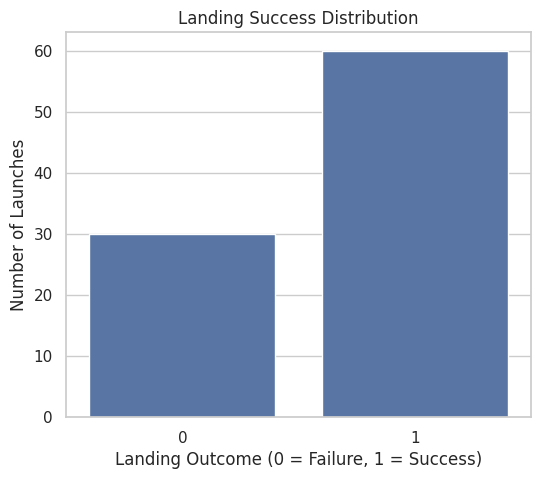

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6,5))

sns.countplot(x='Class', data=df)

plt.title("Landing Success Distribution")
plt.xlabel("Landing Outcome (0 = Failure, 1 = Success)")
plt.ylabel("Number of Launches")

plt.show()

Class
1    66.666667
0    33.333333
Name: proportion, dtype: float64


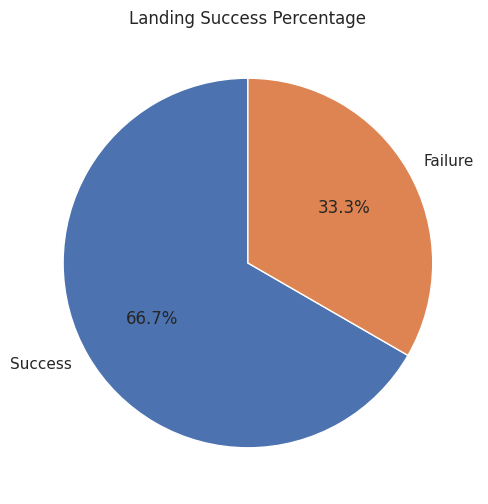

In [21]:
success = df['Class'].value_counts(normalize=True) * 100

print(success)

plt.figure(figsize=(6,6))

plt.pie(
    success,
    labels=['Success','Failure'] if 1 in success.index else success.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Landing Success Percentage")

plt.show()

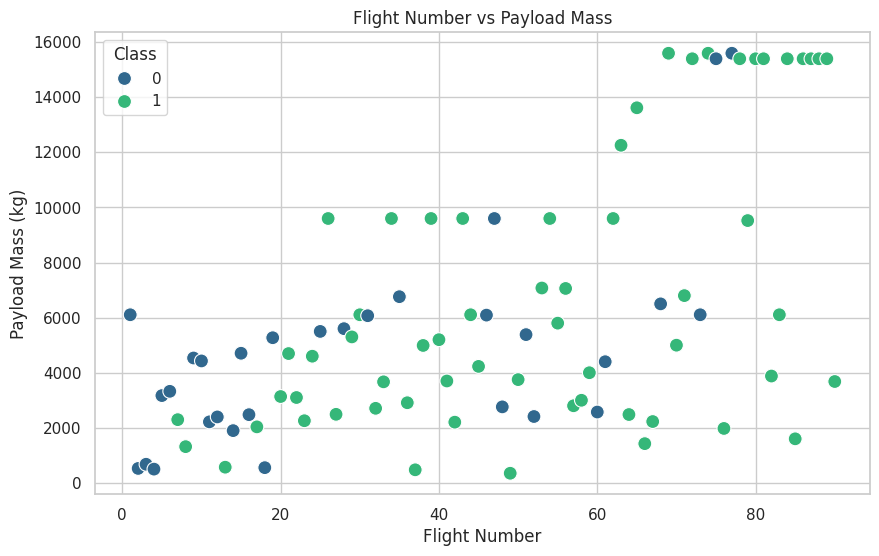

In [22]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='FlightNumber',
    y='PayloadMass',
    hue='Class',
    palette='viridis',
    s=100
)

plt.title("Flight Number vs Payload Mass")
plt.xlabel("Flight Number")
plt.ylabel("Payload Mass (kg)")

plt.show()

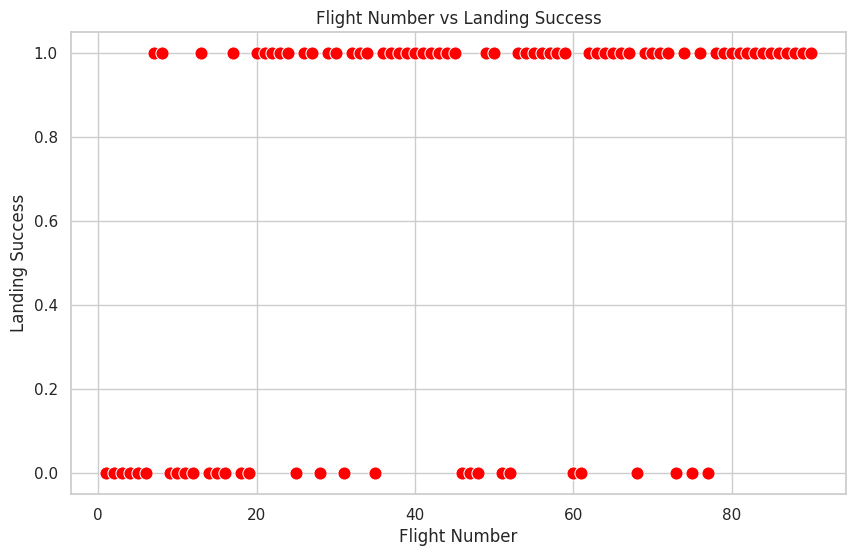

In [23]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='FlightNumber',
    y='Class',
    color='red',
    s=90
)

plt.title("Flight Number vs Landing Success")
plt.xlabel("Flight Number")
plt.ylabel("Landing Success")

plt.show()

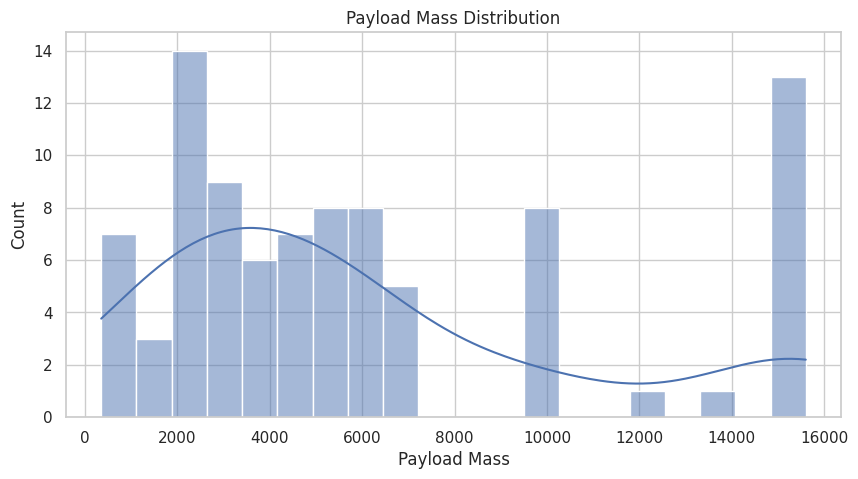

In [24]:
plt.figure(figsize=(10,5))

sns.histplot(df['PayloadMass'], bins=20, kde=True)

plt.title("Payload Mass Distribution")

plt.xlabel("Payload Mass")

plt.show()

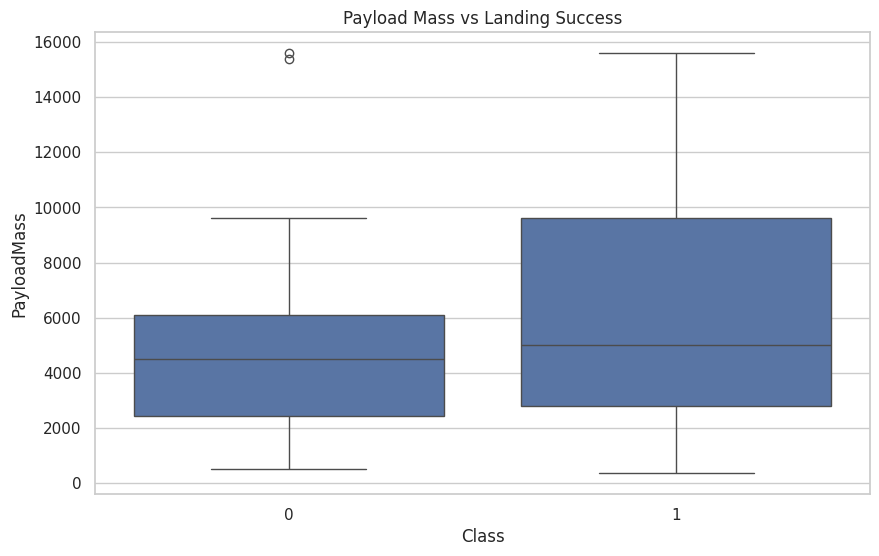

In [25]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Class',
    y='PayloadMass'
)

plt.title("Payload Mass vs Landing Success")

plt.show()

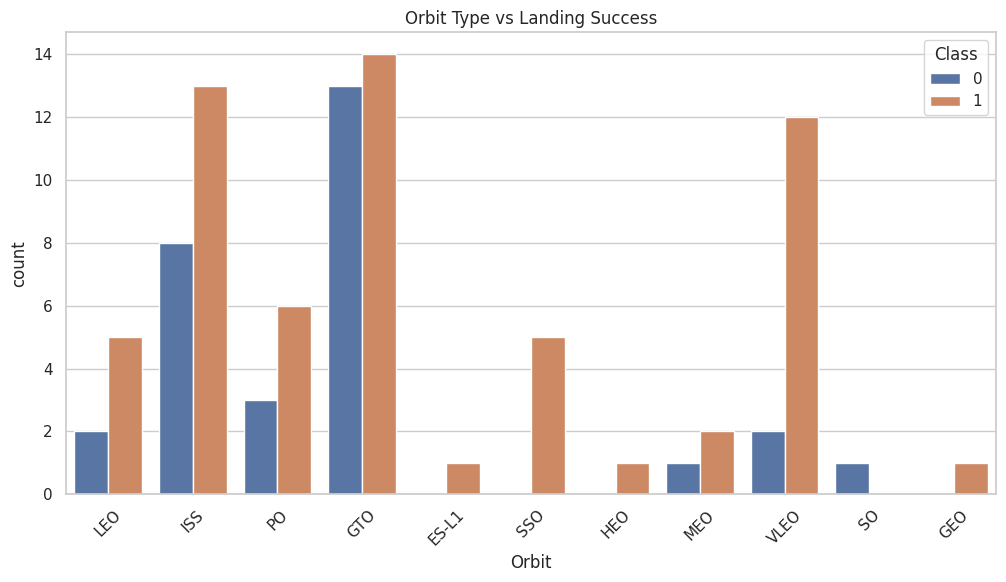

In [26]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='Orbit',
    hue='Class'
)

plt.xticks(rotation=45)

plt.title("Orbit Type vs Landing Success")

plt.show()

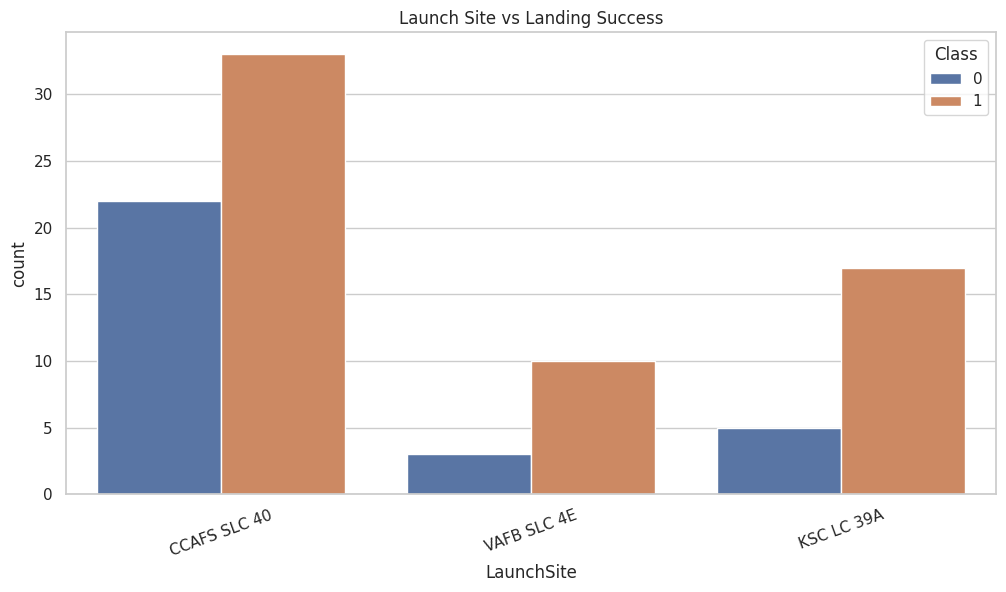

In [27]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='LaunchSite',
    hue='Class'
)

plt.xticks(rotation=20)

plt.title("Launch Site vs Landing Success")

plt.show()

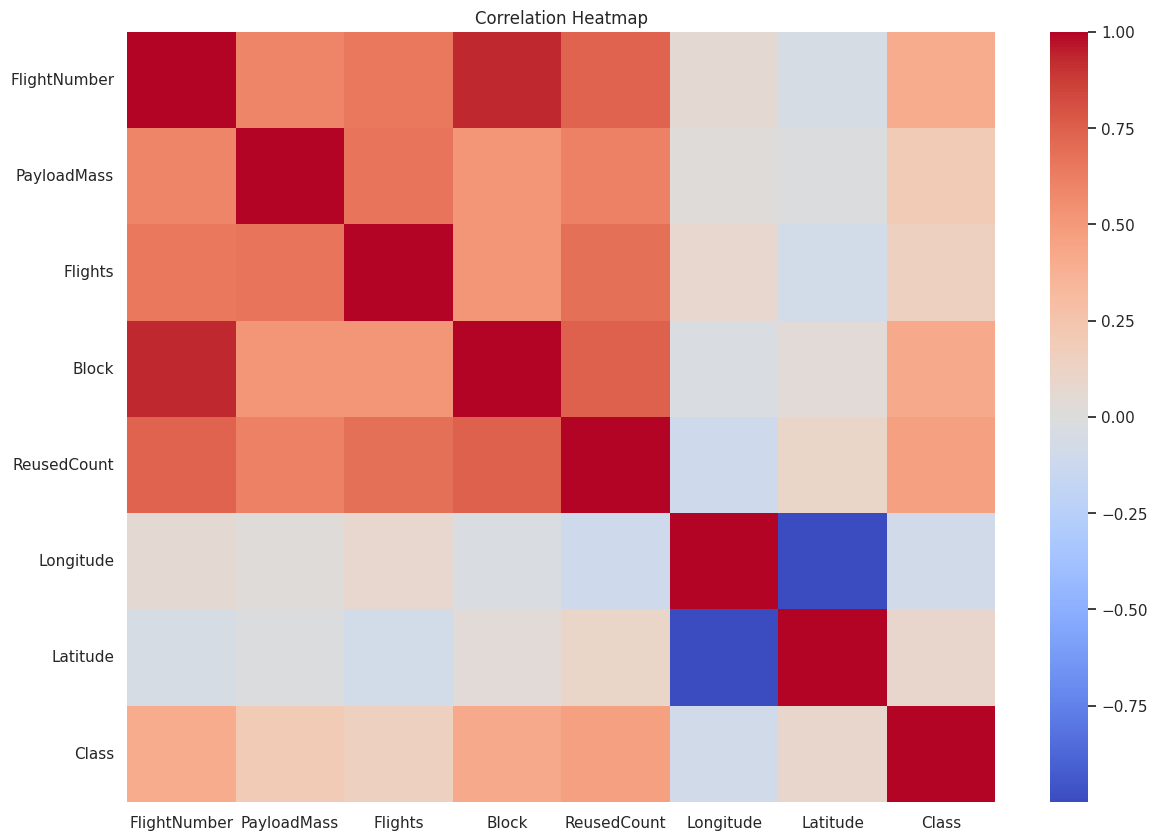

In [28]:
plt.figure(figsize=(14,10))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

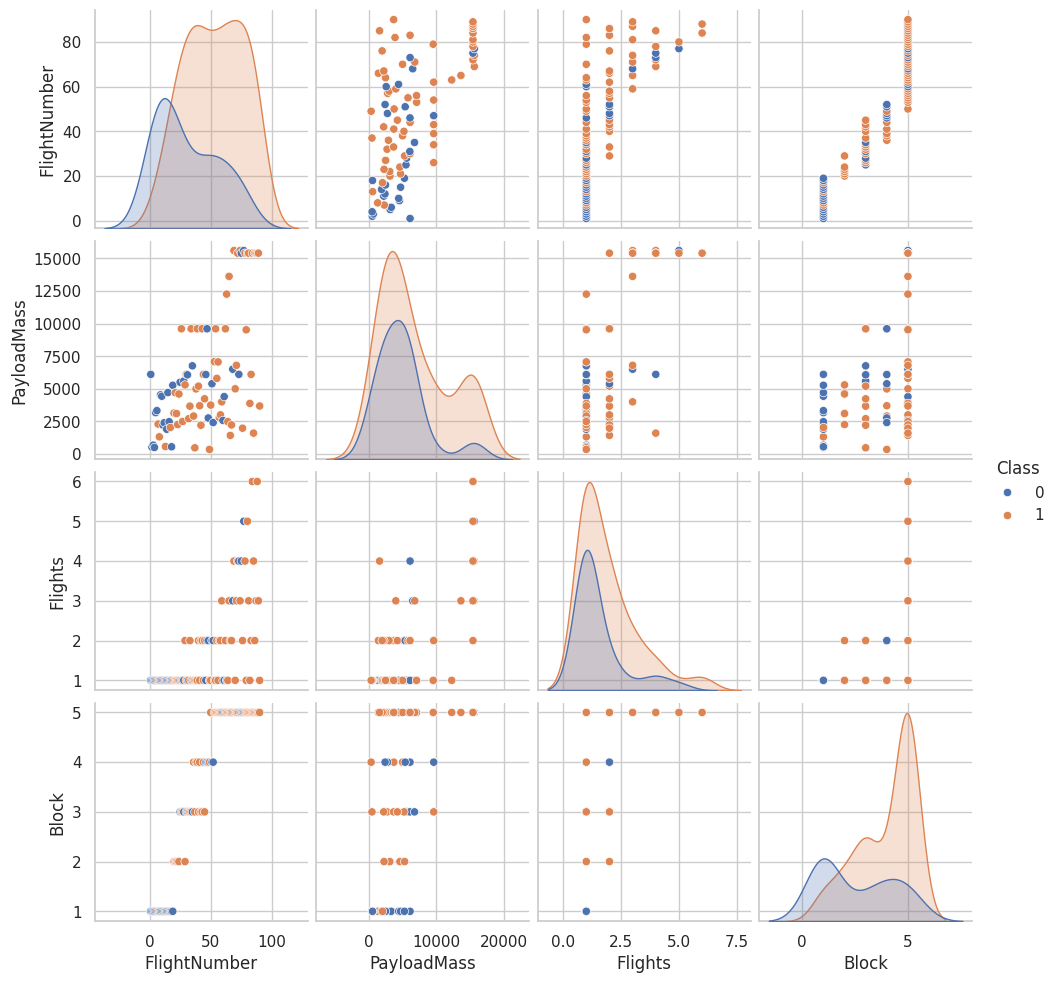

In [29]:
sns.pairplot(
    df[['FlightNumber','PayloadMass','Flights','Block','Class']],
    hue='Class'
)

plt.show()

In [30]:
import sqlite3

In [31]:
conn = sqlite3.connect("SpaceX.db")

In [32]:
df.to_sql(
    "SPACEX",
    conn,
    if_exists="replace",
    index=False
)

print("Database Created Successfully!")

Database Created Successfully!


In [33]:
query = """
SELECT *
FROM SPACEX
LIMIT 5;
"""

pd.read_sql(query, conn)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,0,0,0,None,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,0,0,0,None,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,0,0,0,None,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,0,0,0,None,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,0,0,0,None,1.0,0,B1004,-80.577366,28.561857,0


In [34]:
query = """
SELECT COUNT(*) AS Total_Launches
FROM SPACEX;
"""

pd.read_sql(query, conn)

,Total_Launches
0,90


In [35]:
query = """
SELECT ROUND(AVG(PayloadMass),2) AS Average_Payload
FROM SPACEX;
"""

pd.read_sql(query, conn)

,Average_Payload
0,6104.96


In [36]:
query = """
SELECT MAX(PayloadMass) AS Maximum_Payload
FROM SPACEX;
"""

pd.read_sql(query, conn)

,Maximum_Payload
0,15600.0


In [37]:
query = """
SELECT COUNT(*) AS Successful_Landings
FROM SPACEX
WHERE Class = 1;
"""

pd.read_sql(query, conn)

,Successful_Landings
0,60


In [38]:
query = """
SELECT COUNT(*) AS Failed_Landings
FROM SPACEX
WHERE Class = 0;
"""

pd.read_sql(query, conn)

,Failed_Landings
0,30


In [39]:
query = """
SELECT
LaunchSite,
ROUND(AVG(PayloadMass),2) AS Avg_Payload
FROM SPACEX
GROUP BY LaunchSite;
"""

pd.read_sql(query, conn)

,LaunchSite,Avg_Payload
0,CCAFS SLC 40,5548.21
1,KSC LC 39A,7606.45
2,VAFB SLC 4E,5919.46


In [40]:
query = """
SELECT
LaunchSite,
ROUND(AVG(Class)*100,2) AS Success_Percentage
FROM SPACEX
GROUP BY LaunchSite;
"""

pd.read_sql(query, conn)

,LaunchSite,Success_Percentage
0,CCAFS SLC 40,60.00
1,KSC LC 39A,77.27
2,VAFB SLC 4E,76.92


In [41]:
query = """
SELECT
Orbit,
COUNT(*) AS Launches,
ROUND(AVG(Class)*100,2) AS Success_Rate
FROM SPACEX
GROUP BY Orbit
ORDER BY Success_Rate DESC;
"""

pd.read_sql(query, conn)

,Orbit,Launches,Success_Rate
0,SSO,5,100.00
1,HEO,1,100.00
2,GEO,1,100.00
3,ES-L1,1,100.00
4,VLEO,14,85.71
5,LEO,7,71.43
6,PO,9,66.67
7,MEO,3,66.67
8,ISS,21,61.90
9,GTO,27,51.85


In [42]:
query = """
SELECT
FlightNumber,
PayloadMass,
LaunchSite,
Orbit
FROM SPACEX
ORDER BY PayloadMass DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,FlightNumber,PayloadMass,LaunchSite,Orbit
0,69,15600.0,CCAFS SLC 40,VLEO
1,74,15600.0,CCAFS SLC 40,VLEO
2,77,15600.0,KSC LC 39A,VLEO
3,72,15400.0,CCAFS SLC 40,VLEO
4,75,15400.0,CCAFS SLC 40,VLEO
5,78,15400.0,KSC LC 39A,VLEO
6,80,15400.0,CCAFS SLC 40,VLEO
7,81,15400.0,CCAFS SLC 40,VLEO
8,84,15400.0,CCAFS SLC 40,VLEO
9,86,15400.0,KSC LC 39A,VLEO


In [43]:
query = """
SELECT
Block,
COUNT(*) AS Launches,
ROUND(AVG(Class)*100,2) AS Success_Rate
FROM SPACEX
GROUP BY Block
ORDER BY Block;
"""

pd.read_sql(query, conn)

,Block,Launches,Success_Rate
0,1.0,19,21.05
1,2.0,6,100.00
2,3.0,15,73.33
3,4.0,11,54.55
4,5.0,39,84.62


In [44]:
query = """
SELECT
Flights,
COUNT(*) AS Total,
ROUND(AVG(Class)*100,2) AS Success_Rate
FROM SPACEX
GROUP BY Flights;
"""

pd.read_sql(query, conn)

,Flights,Total,Success_Rate
0,1,53,58.49
1,2,19,78.95
2,3,8,87.50
3,4,6,66.67
4,5,2,50.00
5,6,2,100.00


In [45]:
# Install Folium if needed
!pip install folium

import folium
from folium.plugins import MarkerCluster

In [46]:
# Create a world map centered near Florida
launch_map = folium.Map(
    location=[28.5, -80.6],
    zoom_start=4
)

launch_map

In [47]:
launch_sites = {
    "CCAFS LC-40": [28.562302, -80.577356],
    "CCAFS SLC-40": [28.562302, -80.577356],
    "KSC LC-39A": [28.608389, -80.604333],
    "VAFB SLC-4E": [34.632834, -120.610746]
}

In [48]:
marker_cluster = MarkerCluster().add_to(launch_map)

for site, coord in launch_sites.items():

    folium.Marker(
        location=coord,
        popup=site,
        tooltip=site,
        icon=folium.Icon(color="blue", icon="rocket", prefix="fa")
    ).add_to(marker_cluster)

launch_map

In [49]:
marker_cluster = MarkerCluster().add_to(launch_map)

for site, coord in launch_sites.items():

    folium.Marker(
        location=coord,
        popup=site,
        tooltip=site,
        icon=folium.Icon(color="blue", icon="rocket", prefix="fa")
    ).add_to(marker_cluster)

launch_map

In [50]:
for site, coord in launch_sites.items():

    folium.Circle(
        radius=1000,
        location=coord,
        popup=site,
        color="red",
        fill=True,
        fill_opacity=0.4
    ).add_to(launch_map)

launch_map

In [51]:
launch_map.save("SpaceX_Launch_Map.html")

print("Interactive map saved successfully!")

Interactive map saved successfully!


In [52]:
X = pd.read_csv("dataset_part_3.csv")

y = pd.read_csv("dataset_part_2.csv")["Class"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

X.head()

Feature Shape : (90, 76)
Target Shape : (90,)


,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_GEO,Orbit_GTO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (72, 76)
Testing Samples : (18, 76)


In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy :", round(lr_accuracy*100,2),"%")

Logistic Regression Accuracy : 77.78 %


In [56]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train_scaled, y_train)

svm_pred = svm.predict(X_test_scaled)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy :", round(svm_accuracy*100,2),"%")

SVM Accuracy : 83.33 %


In [57]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)

tree_accuracy = accuracy_score(y_test, tree_pred)

print("Decision Tree Accuracy :", round(tree_accuracy*100,2),"%")

Decision Tree Accuracy : 72.22 %


In [58]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(random_state=42)

forest.fit(X_train, y_train)

forest_pred = forest.predict(X_test)

forest_accuracy = accuracy_score(y_test, forest_pred)

print("Random Forest Accuracy :", round(forest_accuracy*100,2),"%")

Random Forest Accuracy : 72.22 %


In [59]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train_scaled,y_train)

knn_pred = knn.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test,knn_pred)

print("KNN Accuracy :",round(knn_accuracy*100,2),"%")

KNN Accuracy : 77.78 %


In [60]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Support Vector Machine",
        "Decision Tree",
        "Random Forest",
        "K Nearest Neighbors"
    ],

    "Accuracy":[
        lr_accuracy,
        svm_accuracy,
        tree_accuracy,
        forest_accuracy,
        knn_accuracy
    ]

})

results = results.sort_values(
    by="Accuracy",
    ascending=False
)

results

,Model,Accuracy
1,Support Vector Machine,0.833333
0,Logistic Regression,0.777778
4,K Nearest Neighbors,0.777778
2,Decision Tree,0.722222
3,Random Forest,0.722222


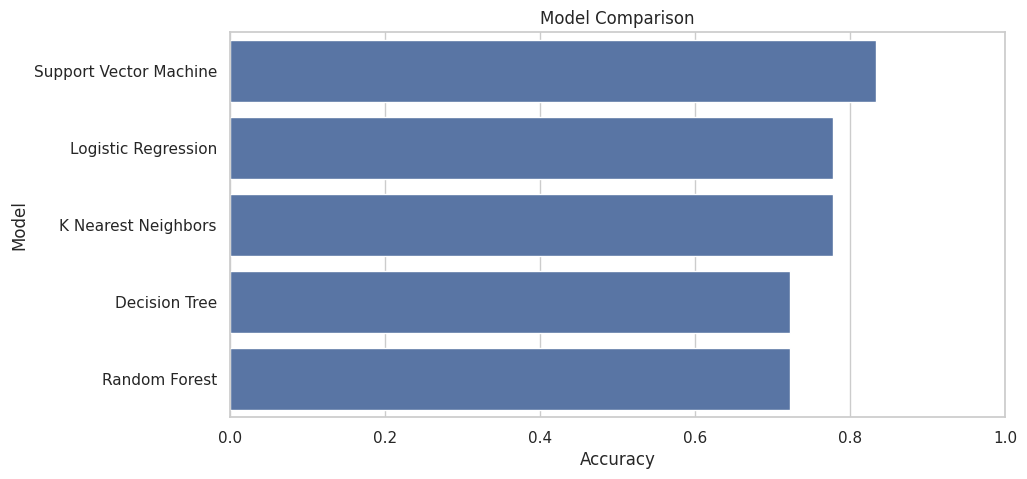

In [61]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results,
    x="Accuracy",
    y="Model"
)

plt.title("Model Comparison")

plt.xlim(0,1)

plt.show()

In [62]:
best_model = results.iloc[0]

print("Best Model")
print(best_model)

Best Model
Model       Support Vector Machine
Accuracy                  0.833333
Name: 1, dtype: object


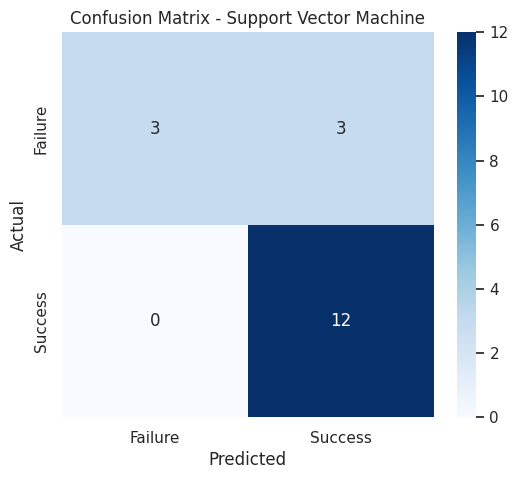

In [65]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Failure", "Success"],
    yticklabels=["Failure", "Success"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Support Vector Machine")

plt.show()

In [66]:
from sklearn.metrics import classification_report

print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         6
           1       0.80      1.00      0.89        12

    accuracy                           0.83        18
   macro avg       0.90      0.75      0.78        18
weighted avg       0.87      0.83      0.81        18



In [67]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear']
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Accuracy:", round(grid.best_score_ * 100, 2), "%")

best_svm = grid.best_estimator_

best_pred = best_svm.predict(X_test_scaled)

print("Test Accuracy:", round(accuracy_score(y_test, best_pred) * 100, 2), "%")

Best Parameters: {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
Best Cross Validation Accuracy: 84.67 %
Test Accuracy: 66.67 %
